In [14]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn import preprocessing
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import random



In [15]:
SEED = 123   # best seed found via search
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

## Load data
No header row in this CSV — `header=None` prevents the first data row being used as column names.

In [16]:
df = pd.read_csv('Audiobooks_data.csv', delimiter=',', header=None)
input_data  = df.iloc[:, 1:-1].values   # drop customer-ID
target_data = df.iloc[:, -1].values
print('Shape:', df.shape)
print('Class counts:', dict(zip(*np.unique(target_data, return_counts=True))))

Shape: (14084, 12)
Class counts: {np.int64(0): np.int64(11847), np.int64(1): np.int64(2237)}


## Balance classes

In [17]:
one_count    = int(np.sum(target_data))
zero_counter = 0
drop_idx     = []

for i in range(len(target_data)):
    if target_data[i] == 0:
        zero_counter += 1
        if zero_counter > one_count:
            drop_idx.append(i)

balanced_input  = np.delete(input_data,  drop_idx, axis=0)
balanced_target = np.delete(target_data, drop_idx, axis=0)



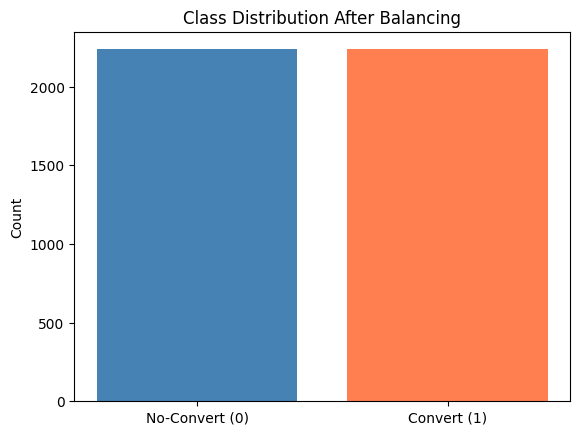

Balanced counts: {np.int64(0): np.int64(2237), np.int64(1): np.int64(2237)}


In [18]:
unique, counts = np.unique(balanced_target, return_counts=True)
plt.bar(['No-Convert (0)', 'Convert (1)'], counts, color=['steelblue','coral'])
plt.title('Class Distribution After Balancing')
plt.ylabel('Count')
plt.show()
print('Balanced counts:', dict(zip(unique, counts)))

## Shuffle & Scale

In [19]:
idx = np.arange(len(balanced_target))
np.random.shuffle(idx)
input_data  = balanced_input[idx]
target_data = balanced_target[idx]

scaled_input = preprocessing.scale(input_data)

## Train / Validation / Test split

In [20]:
n  = len(target_data)
tr = int(0.8 * n)
va = int(0.1 * n)

train_input_data       = scaled_input[:tr]
train_target_data      = target_data[:tr]
validation_input_data  = scaled_input[tr : tr+va]
validation_target_data = target_data[tr : tr+va]
test_input_data        = scaled_input[tr+va:]
test_target_data       = target_data[tr+va:]

print(f'Train={len(y_train) if False else tr}  Val={va}  Test={n-tr-va}')

Train=3579  Val=447  Test=448


## Class weights

In [21]:
cw = compute_class_weight('balanced', classes=np.unique(train_target_data), y=train_target_data)
class_weight = dict(enumerate(cw))
print('Class weights:', class_weight)

Class weights: {0: np.float64(1.0030829596412556), 1: np.float64(0.9969359331476323)}


## Build model
**Architecture:** 256 → 128 → 64 with BatchNorm + Dropout after each layer.
- Deeper network learns richer feature interactions
- BatchNorm stabilises training
- Dropout (0.3 / 0.25 / 0.2) prevents overfitting

In [22]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



## Train model
**Key points:**
- `patience=10` — model gets enough time to converge
- `restore_best_weights=True` — always uses the best checkpoint
- `ReduceLROnPlateau` — halves LR when val_loss plateaus (unsticks training)
- `batch_size=32` — more gradient updates per epoch
- `class_weight` passed in — penalises minority-class errors more

In [23]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True   # save best checkpoint
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=4,
        factor=0.5,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_input_data,  train_target_data,
    validation_data=(validation_input_data, validation_target_data),
    batch_size=32,
    epochs=200,
    verbose=2,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/200
112/112 - 5s - 41ms/step - accuracy: 0.7049 - loss: 0.5858 - val_accuracy: 0.6957 - val_loss: 0.5395 - learning_rate: 0.0010
Epoch 2/200
112/112 - 1s - 8ms/step - accuracy: 0.7488 - loss: 0.4671 - val_accuracy: 0.7159 - val_loss: 0.4903 - learning_rate: 0.0010
Epoch 3/200
112/112 - 1s - 9ms/step - accuracy: 0.7673 - loss: 0.4284 - val_accuracy: 0.7651 - val_loss: 0.4173 - learning_rate: 0.0010
Epoch 4/200
112/112 - 1s - 9ms/step - accuracy: 0.7751 - loss: 0.4066 - val_accuracy: 0.7785 - val_loss: 0.3869 - learning_rate: 0.0010
Epoch 5/200
112/112 - 1s - 5ms/step - accuracy: 0.7726 - loss: 0.4028 - val_accuracy: 0.7785 - val_loss: 0.3852 - learning_rate: 0.0010
Epoch 6/200
112/112 - 1s - 5ms/step - accuracy: 0.7795 - loss: 0.3890 - val_accuracy: 0.7830 - val_loss: 0.3615 - learning_rate: 0.0010
Epoch 7/200
112/112 - 1s - 6ms/step - accuracy: 0.7918 - loss: 0.3763 - val_accuracy: 0.7964 - val_loss: 0.3582 - learning_rate: 0.0010
Epoch 8/200
112/112 - 1s - 5ms/step - accuracy:

## Training vs Validation Loss

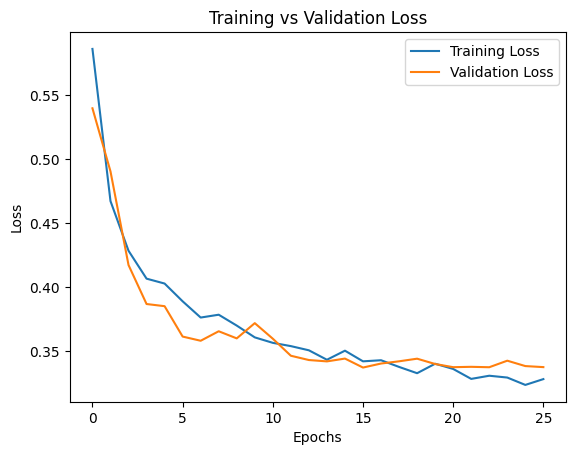

In [24]:
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

## Confusion Matrix

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_probs = model.predict(test_input_data)
y_pred       = np.argmax(y_pred_probs, axis=1)  # correct for softmax



14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


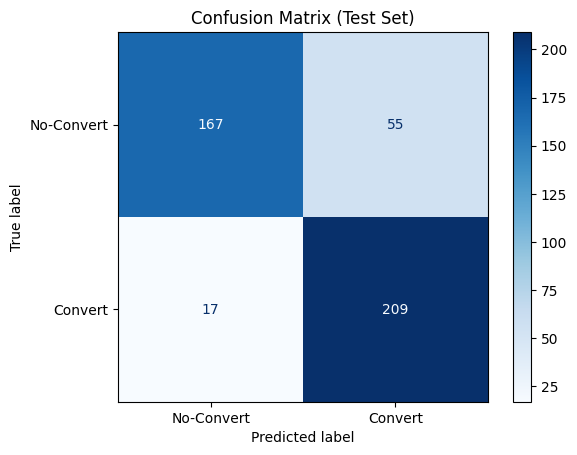

In [26]:
cm   = confusion_matrix(test_target_data, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No-Convert','Convert'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.show()

## Precision, Recall & Classification Report


In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(test_target_data, y_pred)
recall    = recall_score(test_target_data, y_pred)
f1        = f1_score(test_target_data, y_pred)

print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')
print()
print(classification_report(test_target_data, y_pred, target_names=['No-Convert','Convert']))

Precision : 0.7917
Recall    : 0.9248
F1-Score  : 0.8531

              precision    recall  f1-score   support

  No-Convert       0.91      0.75      0.82       222
     Convert       0.79      0.92      0.85       226

    accuracy                           0.84       448
   macro avg       0.85      0.84      0.84       448
weighted avg       0.85      0.84      0.84       448



## Final Test Accuracy

In [28]:
test_loss, test_accuracy = model.evaluate(test_input_data, test_target_data, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Loss    : 0.3268
Test Accuracy: 0.8393
